In [ ]:
#Load Libraries
library(Seurat)
library(SeuratDisk)
library(Signac)
library(AnnotationHub)
library(Matrix)
library(future)
library(reticulate)
library(sceasy)
library(MuDataSeurat)
library(hdf5r)
library(ggplot2)
library(ComplexHeatmap)
library(circlize)
library(grid)
library(viridis)

#Set Options
options(future.globals.maxSize = 400000 * 1024^2) #for 400GB max size
plan("sequential")

#Set working directory
setwd("/storage1/fs1/jmillman/Active/DigitalTwin")

set.seed(777)

# Annotate DT

In [88]:
data.muon <- readRDS("checkpoints/DT_muon_preprocess.rds")
data.muon

An object of class Seurat 
95325 features across 401519 samples within 2 assays 
Active assay: RNA (17015 features, 5000 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC
 17 dimensional reductions calculated: RNAHARMONY, RNAINTEGRATED_LSI, RNAMULTIVI, RNAPCA, RNAUMAP, RNAUMAP.HARMONY, RNAUMAP.INTEGRATED.ATAC, RNAUMAP.MERGED.RNA, ATACHARMONY, ATACINTEGRATED_LSI, ATACMULTIVI, ATACPCA, ATACUMAP, ATACUMAP.HARMONY, ATACUMAP.INTEGRATED.ATAC, ATACUMAP.MERGED.RNA, umap.multivi

In [89]:
colnames(data.muon)

An object of class Seurat 
95325 features across 401519 samples within 2 assays 
Active assay: RNA (17015 features, 5000 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC
 17 dimensional reductions calculated: RNAHARMONY, RNAINTEGRATED_LSI, RNAMULTIVI, RNAPCA, RNAUMAP, RNAUMAP.HARMONY, RNAUMAP.INTEGRATED.ATAC, RNAUMAP.MERGED.RNA, ATACHARMONY, ATACINTEGRATED_LSI, ATACMULTIVI, ATACPCA, ATACUMAP, ATACUMAP.HARMONY, ATACUMAP.INTEGRATED.ATAC, ATACUMAP.MERGED.RNA, umap.multivi

In [90]:
## Map dataset name -> RDS path + celltype column to pull
spec <- list(
  Zhu        = list(path = "checkpoints/DT_muon_zhu.rds",        col = "celltype_Zhu"),
  Weng       = list(path = "checkpoints/DT_muon_weng.rds",       col = "celltype_Weng"),
  Veres     = list(path = "checkpoints/DT_muon_veres.rds",    col = "celltype_Veres"),
  Rezania    = list(path = "checkpoints/DT_muon_rezania.rds", col = "celltype_Rezania"),
  Millman    = list(path = "checkpoints/DT_muon_millman.rds",    col = "celltype_Millman"),
  Hua        = list(path = "checkpoints/DT_muon_hua.rds",        col = "celltype_Hua"),
  Balboa     = list(path = "checkpoints/DT_muon_balboa.rds",     col = "celltype_Balboa")
)

pieces <- vector("list", length(spec))
k <- 1L

for (nm in names(spec)) {
  p <- spec[[nm]]$path
  colname <- spec[[nm]]$col

  obj <- readRDS(p)
  meta <- obj[[]]

  if (!colname %in% colnames(meta)) {
    rm(obj); gc()
    stop(sprintf("Column '%s' not found in %s. Available: %s",
                 colname, nm, paste(colnames(meta), collapse = ", ")))
  }

  df <- data.frame(
    cell = rownames(meta),
    celltype_labelled_by_protocol = as.character(meta[[colname]]),
    dataset = nm,
    stringsAsFactors = FALSE
  )
  df <- df[!duplicated(df$cell), , drop = FALSE]

  ## OPTIONAL: ensure global uniqueness of barcodes across datasets
  ## df$cell <- paste0(df$cell, "_", nm)

  pieces[[k]] <- df
  k <- k + 1L

  ## Free memory from the large Seurat object before next iteration
  rm(obj, meta, df); gc()
}

celltype_df <- do.call(rbind, pieces)
row.names(celltype_df) <- NULL

## Quick peek
dim(celltype_df)
head(celltype_df, 5)


[1] 401519      3

,cell,celltype_labelled_by_protocol,dataset
,<chr>,<chr>,<chr>
1,zhu.d11_AAACCCAAGAACTGAT-1_expression,PP,Zhu
2,zhu.d11_AAACCCAAGACATCAA-1_expression,eEP,Zhu
3,zhu.d11_AAACCCACAACTGTGT-1_expression,PP,Zhu
4,zhu.d11_AAACCCACAAGAGATT-1_expression,eEP,Zhu
5,zhu.d11_AAACCCACAGGTTCGC-1_expression,lEP,Zhu


In [93]:
#Correct the names since 9 time points came from an independent analysis
celltype_df$cell <- ifelse(
  grepl("-1$", celltype_df$cell),                # only names ending in "-1"
  paste0(celltype_df$cell, "_paired"),          # add suffix
  celltype_df$cell                              # leave others unchanged
)


In [94]:
millman_df <- subset(celltype_df, dataset == "Millman")
head(millman_df)

,cell,celltype_labelled_by_protocol,dataset
,<chr>,<chr>,<chr>
240253,punn.sci1_CGCCTGTGTGAGCAAG-1_paired,Beta,Millman
240254,punn.sciw3_GTACTTAAGATGGAGC-1_paired,Alpha,Millman
240255,s4d2_TCTATGTTCGGTACGC-1_paired,Prolif.,Millman
240256,s4d2_CATCCCAGTGTGAGAG-1_paired,PP,Millman
240257,s4d2_GGCTGGTTCCCTGACT-1_paired,PP,Millman
240258,punn.sci3_TCTCAAGCAACCGCCA-1_paired,Alpha,Millman


In [95]:
write.csv(celltype_df, file = "checkpoints/DT_celltype_labelled_by_protocol_df.csv", row.names = FALSE)


In [77]:
#celltype_df <- read.csv("checkpoints/DT_celltype_labelled_by_protocol_df.csv", stringsAsFactors = FALSE)


In [96]:
# Ensure character vectors
cells_data.muon  <- as.character(rownames(data.muon@meta.data))
cells_df  <- as.character(celltype_df$cell)

# Cells present only in data.muon_ATAC or only in celltype_df
data.muon_only   <- setdiff(cells_data.muon, cells_df)
df_only   <- setdiff(cells_df, cells_data.muon)

# Make a two-column table (wide) for easy viewing/export
nmax <- max(length(data.muon_only), length(df_only))
pad  <- function(x, n) { c(x, rep(NA_character_, n - length(x))) }

nonmatch_wide <- data.frame(
  data.muon_only      = pad(data.muon_only, nmax),
  celltype_df_only  = pad(df_only, nmax),
  stringsAsFactors = FALSE
)

# Peek
head(nonmatch_wide, 10)

# (Optional) counts
c(data.muon_only = length(data.muon_only), celltype_df_only = length(df_only))

# How many are in common?
common <- intersect(cells_data.muon, cells_df)
n_common <- length(common)

# Quick summary
summary_counts <- data.frame(
  total_data.muon      = length(cells_data.muon),
  total_celltype_df  = length(cells_df),
  in_common          = n_common,
  data.muon_only       = length(data.muon_only),
  celltype_df_only   = length(df_only),
  jaccard_index      = n_common / (length(cells_data.muon) + length(cells_df) - n_common)
)
summary_counts


data.muon_only,celltype_df_only
<chr>,<chr>


data.muon_only celltype_df_only 
               0                0

total_data.muon,total_celltype_df,in_common,data.muon_only,celltype_df_only,jaccard_index
<int>,<int>,<int>,<int>,<int>,<dbl>
401519,401519,401519,0,0,1


In [97]:
head(df_only)

character(0)

In [98]:
head(data.muon_only)

character(0)

In [99]:
# Add a column 'cell' in data.muon@meta.data with the barcodes
if ("cell" %in% colnames(data.muon[[]])) {
  message("Column 'cell' already exists in data.muon; overwriting it.")
}
data.muon$cell <- colnames(data.muon)

# Sanity checks
stopifnot(ncol(data.muon) == nrow(data.muon@meta.data))
stopifnot(all(data.muon$cell == rownames(data.muon@meta.data)))

# Peek
head(data.muon$cell)

# Ensure character types (avoid factor issues)
data.muon@meta.data$cell <- as.character(data.muon@meta.data$cell)
celltype_df$cell <- as.character(celltype_df$cell)
celltype_df$celltype_labelled_by_protocol <- as.character(celltype_df$celltype_labelled_by_protocol)

# Initialize to "Z"
data.muon@meta.data$celltype_labelled_by_protocol <- "Z"

# Loop over each row of celltype_df and assign
for (i in seq_len(nrow(celltype_df))) {
  cell_i <- celltype_df$cell[i]
  ann_i  <- celltype_df$celltype_labelled_by_protocol[i]
  data.muon@meta.data$celltype_labelled_by_protocol[data.muon@meta.data$cell %in% cell_i] <- ann_i
}

Column 'cell' already exists in data.muon; overwriting it.



punn.sci1_CGCCTGTGTGAGCAAG-1_paired   punn.sciw3_GTACTTAAGATGGAGC-1_paired 
 "punn.sci1_CGCCTGTGTGAGCAAG-1_paired" "punn.sciw3_GTACTTAAGATGGAGC-1_paired" 
        s4d2_TCTATGTTCGGTACGC-1_paired         s4d2_CATCCCAGTGTGAGAG-1_paired 
      "s4d2_TCTATGTTCGGTACGC-1_paired"       "s4d2_CATCCCAGTGTGAGAG-1_paired" 
        s4d2_GGCTGGTTCCCTGACT-1_paired    punn.sci3_TCTCAAGCAACCGCCA-1_paired 
      "s4d2_GGCTGGTTCCCTGACT-1_paired"  "punn.sci3_TCTCAAGCAACCGCCA-1_paired"

In [100]:
# count the frequency of each unique value of 'orig.ident'
cell_count <- table(data.muon@meta.data$celltype_labelled_by_protocol)
cell_count


   Alpha     Beta       DE    Delta       EC      eEP      Exo       GT 
   74489    50079    28454     7660    60211    35793    16449     2791 
     lEP Mesench.       PP  Prolif.        Z 
   43091     5453    50244    23350     3455 

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



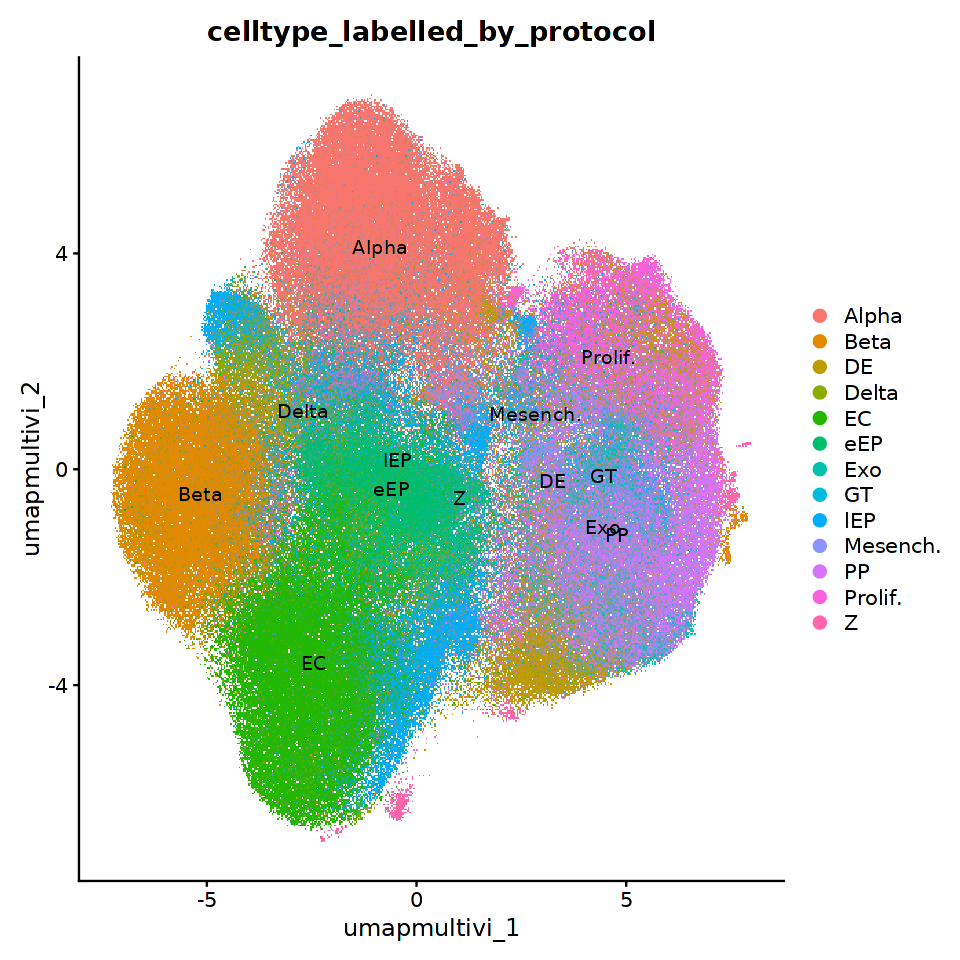

In [101]:
options(repr.plot.width = 8, repr.plot.height = 8)
DimPlot(data.muon, reduction = 'umap.multivi', group.by = 'celltype_labelled_by_protocol', label=T) 

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



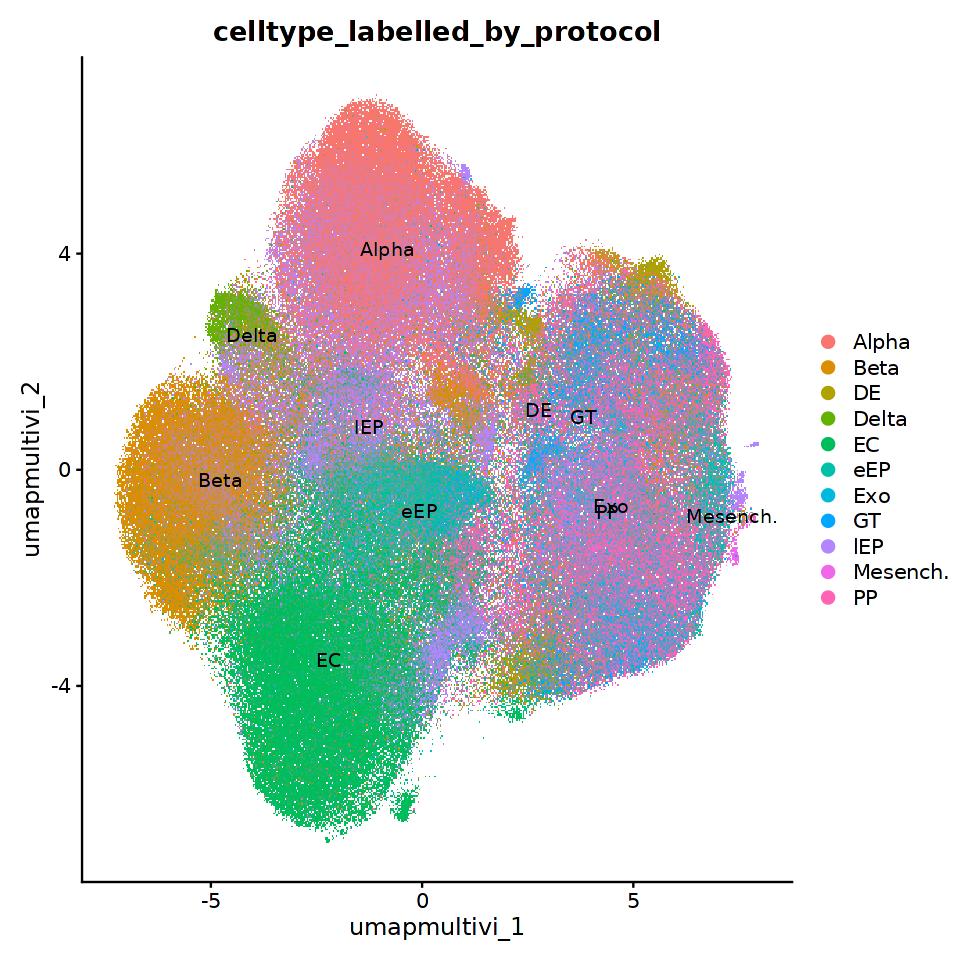

In [84]:
options(repr.plot.width = 8, repr.plot.height = 8)
DimPlot(data.muon, reduction = 'umap.multivi', group.by = 'celltype_labelled_by_protocol', label=T) 

In [108]:
colnames(data.muon[[]])

[1] "orig.ident"                    "nCount_RNA"                   
 [3] "nFeature_RNA"                  "nCount_ATAC"                  
 [5] "nFeature_ATAC"                 "modality"                     
 [7] "dataset"                       "protocol"                     
 [9] "stage"                         "day"                          
[11] "cellsource"                    "gender"                       
[13] "_indices"                      "_scvi_batch"                  
[15] "_scvi_labels"                  "modality.1"                   
[17] "dataset.1"                     "protocol.1"                   
[19] "stage.1"                       "day.1"                        
[21] "cellsource.1"                  "gender.1"                     
[23] "_indices.1"                    "_scvi_batch.1"                
[25] "_scvi_labels.1"                "multivi_clusters"             
[27] "cell"                          "celltype_labelled_by_protocol"

In [104]:
Idents(data.muon) <- 'celltype_labelled_by_protocol'
data.muon <- subset(data.muon, idents='Z', invert=TRUE)
data.muon


An object of class Seurat 
95325 features across 398064 samples within 2 assays 
Active assay: RNA (17015 features, 5000 variable features)
 2 layers present: counts, data
 1 other assay present: ATAC
 17 dimensional reductions calculated: RNAHARMONY, RNAINTEGRATED_LSI, RNAMULTIVI, RNAPCA, RNAUMAP, RNAUMAP.HARMONY, RNAUMAP.INTEGRATED.ATAC, RNAUMAP.MERGED.RNA, ATACHARMONY, ATACINTEGRATED_LSI, ATACMULTIVI, ATACPCA, ATACUMAP, ATACUMAP.HARMONY, ATACUMAP.INTEGRATED.ATAC, ATACUMAP.MERGED.RNA, umap.multivi

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



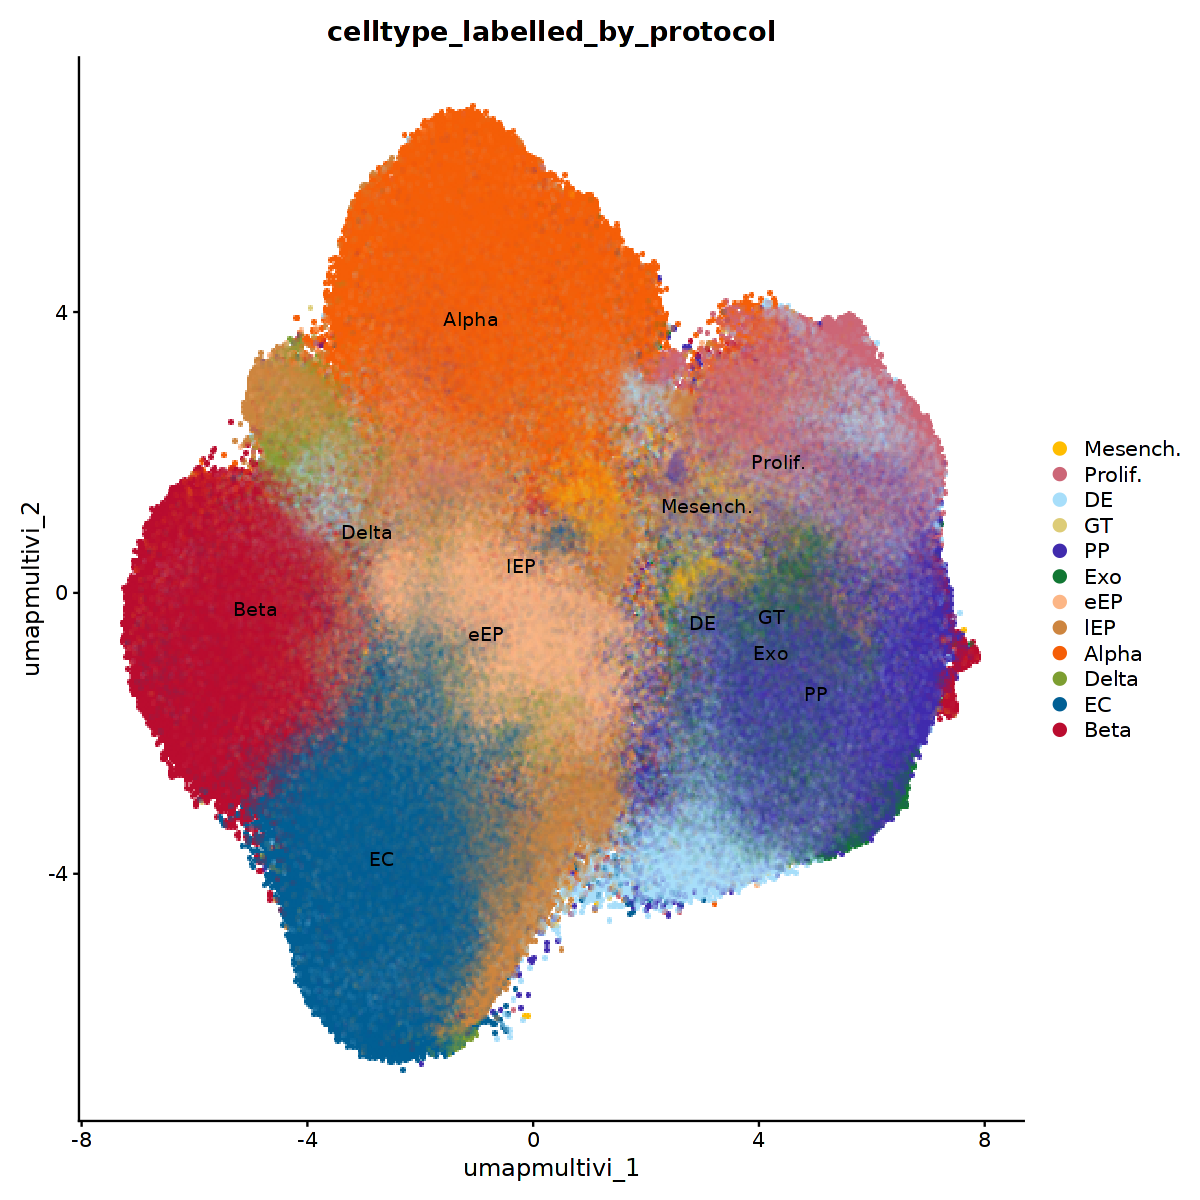

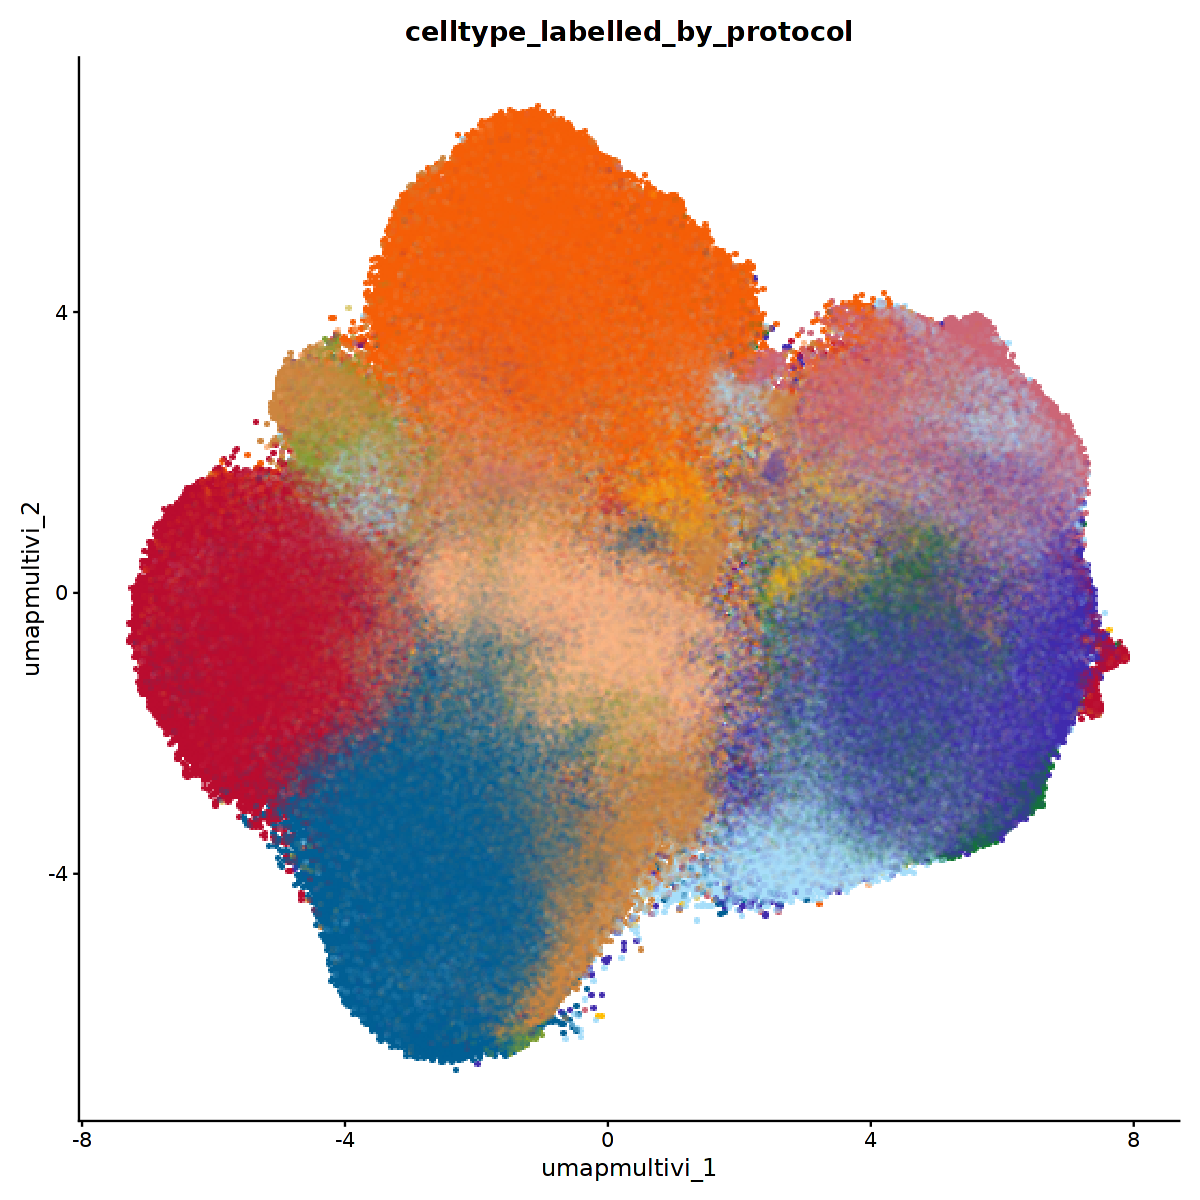

In [105]:
options(repr.plot.width = 10, repr.plot.height = 10)

# Define the desired order
desired_order <- c('Mesench.',
                   'UE',
                   'Prolif.',
                   'DE',
                   'GT',
                   'PP',
                   'Exo',
                   'eEP',
                   'lEP',
                   'Alpha',
                   'Delta',
                   'SIC',
                   'Beta'
)

pal <- c(
        "Mesench." = "#ffbd00",  # yellow
        "UE"       = "#EE3377", # magenta / raspberry
        "Prolif."  = "#CC6677", # dusty rose / muted red
        "DE"       = "#a7defa", # light sky blue
        "GT"       = "#DDCC77", # warm sand / golden khaki
        "PP"       = "#402bad", # deep indigo
        "Exo" = "#117733", # forest green
        "eEP"      = "#fcb686", # light orange
        "lEP"       = '#cd853f', #Peru color
        "Alpha"    = "#f55e07", # vivid orange
        "Delta"    = "#7d9e31", # olive
        "SIC"       = "#015f94", # royal blue
        "Beta"     = "#ba0c2f" # WashU red
  )
    
# Set celltype as a factor with your custom order

data.muon$celltype_labelled_by_protocol <- factor(data.muon$celltype_labelled_by_protocol, levels = desired_order)

DimPlot(data.muon, label = TRUE, repel = TRUE, 
        reduction = "umap.multivi",group.by = 'celltype_labelled_by_protocol', cols=pal,pt.size = 2) 

DimPlot(data.muon, label = FALSE,  repel = TRUE, 
        reduction = "umap.multivi",group.by = 'celltype_labelled_by_protocol', cols=pal,pt.size = 2)  + theme(legend.position = "none")


In [106]:
# count the frequency of each unique value of 'orig.ident'
cell_count <- table(data.muon@meta.data$celltype_labelled_by_protocol)
cell_count


Mesench.       UE  Prolif.       DE       GT       PP      Exo      eEP 
    5453        0    23350    28454     2791    50244    16449    35793 
     lEP    Alpha    Delta       EC     Beta 
   43091    74489     7660    60211    50079 

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



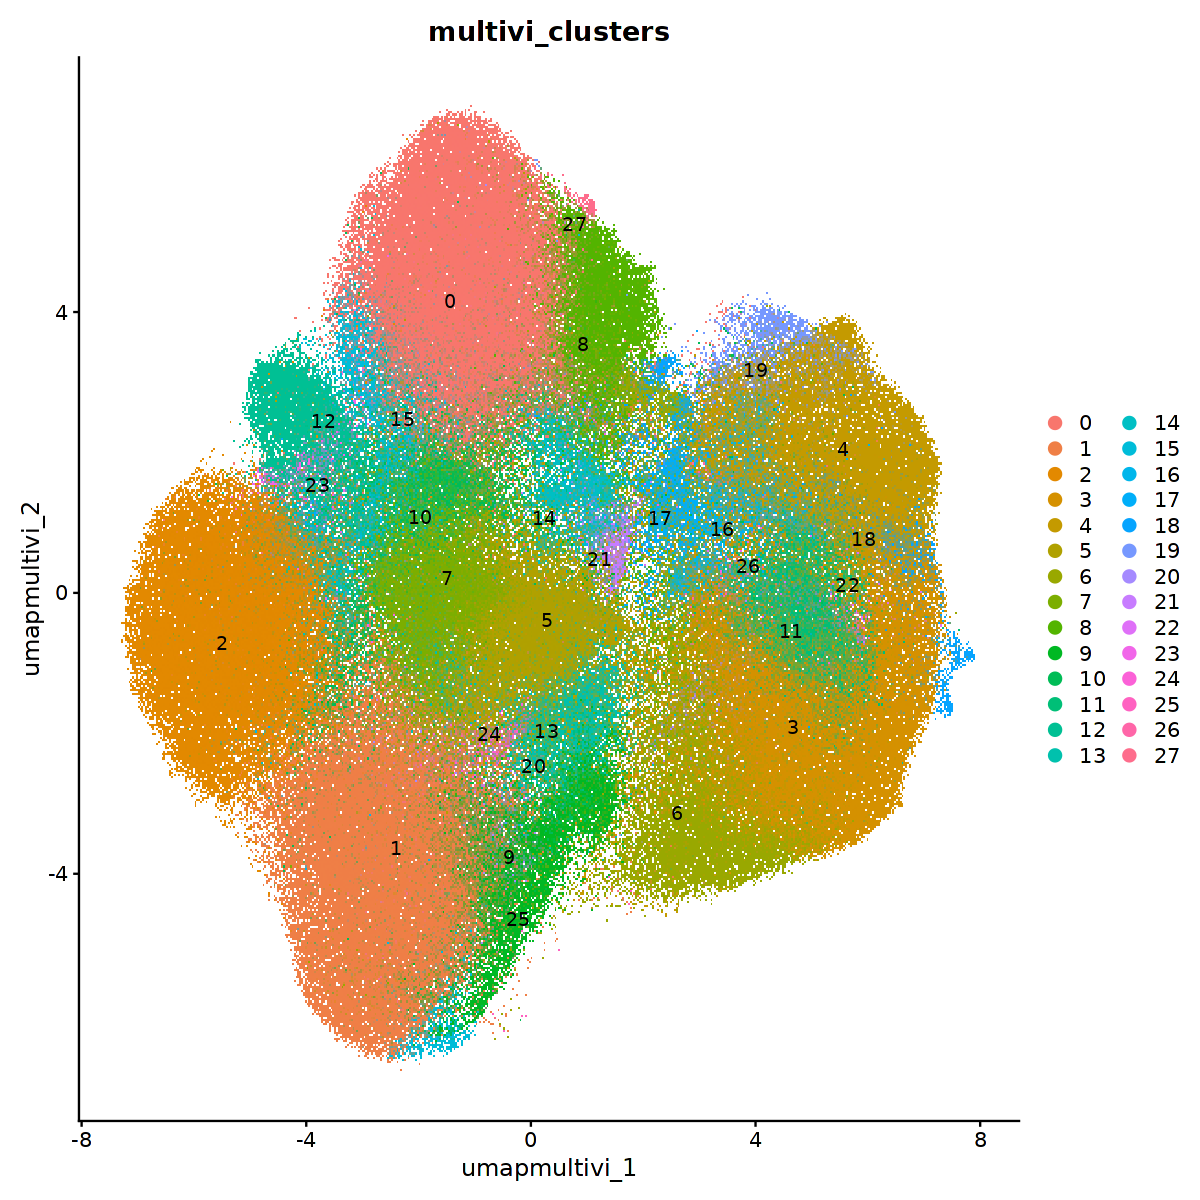

In [109]:
DimPlot(data.muon, label = TRUE, repel = TRUE, 
        reduction = "umap.multivi",group.by = 'multivi_clusters') 

In [110]:
# Save
saveRDS(data.muon, file="checkpoints/DT_muon_annotated.rds")